In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler, LabelEncoder

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


In [2]:
df = pd.read_csv('data/Shopping Mall Customer Segmentation Data .csv')

print('Dataset Shape:', df.shape)
print(f'Total Customers: {len(df):,}')
print(f'Total Features : {df.shape[1]}')
print()
print('First 10 rows:')
df.head(10)

Dataset Shape: (15079, 5)
Total Customers: 15,079
Total Features : 5

First 10 rows:


,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76
5,7e211337-e92f-4140-8231-5c9ac7a2aa12,42,Male,158335,40
6,30661d57-eeb5-4886-970a-9c7d0f260ad8,27,Female,163501,37
7,43417ade-6b17-431e-ae76-d8ed26aa46ac,24,Male,70476,17
8,86f73b1a-6a91-4d7e-ad21-0aefcf6111cc,83,Male,47743,34
9,b20fe0a0-e254-4116-b804-5403bb2f59ea,62,Female,63448,3


In [3]:
print('─' * 45)
print('  COLUMN INFO')
print('─' * 45)
df.info()

─────────────────────────────────────────────
  COLUMN INFO
─────────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15079 entries, 0 to 15078
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Customer ID     15079 non-null  object
 1   Age             15079 non-null  int64 
 2   Gender          15079 non-null  object
 3   Annual Income   15079 non-null  int64 
 4   Spending Score  15079 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 589.2+ KB


In [4]:
print('Missing Values per Column:')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)
print()
if missing.sum() == 0:
    print('✅ No missing values found!')
else:
    print(f'⚠️  Total missing values: {missing.sum()}')

Missing Values per Column:
                Missing Count  Missing %
Customer ID                 0        0.0
Age                         0        0.0
Gender                      0        0.0
Annual Income               0        0.0
Spending Score              0        0.0

✅ No missing values found!


In [5]:
print('Duplicate Rows:', df.duplicated().sum())
print()
print('Gender Distribution:')
gender_counts = df['Gender'].value_counts()
gender_pct = df['Gender'].value_counts(normalize=True).mul(100).round(2)
gender_df = pd.DataFrame({'Count': gender_counts, 'Percentage %': gender_pct})
print(gender_df)

Duplicate Rows: 0

Gender Distribution:
        Count  Percentage %
Gender                     
Male     7595         50.37
Female   7484         49.63


## Prototype Preprocessing Plan

For the prototype, the goal is to turn the raw customer data into a clustering-ready table:

1. Clean the column names.
2. Drop `Customer ID` because it is only an identifier.
3. Encode `Gender` into numeric form.
4. Scale the numeric features so clustering is not biased by large values.
5. Use a 2D projection for a quick visual check before clustering.

In [6]:
from sklearn.decomposition import PCA

# Prototype preprocessing pipeline for clustering
prototype_df = df.copy()
prototype_df.columns = [column.strip().replace(' ', '_') for column in prototype_df.columns]

if 'Customer_ID' in prototype_df.columns:
    prototype_df = prototype_df.drop(columns=['Customer_ID'])

label_encoder = LabelEncoder()
prototype_df['Gender'] = label_encoder.fit_transform(prototype_df['Gender'])

gender_labels = prototype_df['Gender'].copy()
feature_columns = ['Age', 'Annual_Income', 'Spending_Score']

scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_columns)

pca = PCA(n_components=2, random_state=42)
X_pca = pd.DataFrame(pca.fit_transform(X_scaled), columns=['PC1', 'PC2'])

print('Prototype-ready feature matrix shape:', X_scaled.shape)
print('Feature columns:', feature_columns)
print()
print('Scaled feature preview:')
display(X_scaled.head())
print()
print('PCA explained variance ratio:', pca.explained_variance_ratio_.round(4).tolist())
print('2D projection preview:')
display(X_pca.head())

X_scaled_with_gender = X_scaled.copy()
X_scaled_with_gender['Gender'] = gender_labels.values
X_scaled_with_gender.to_csv('data/data_preprocessed.csv', index=False)

NameError: name 'X' is not defined

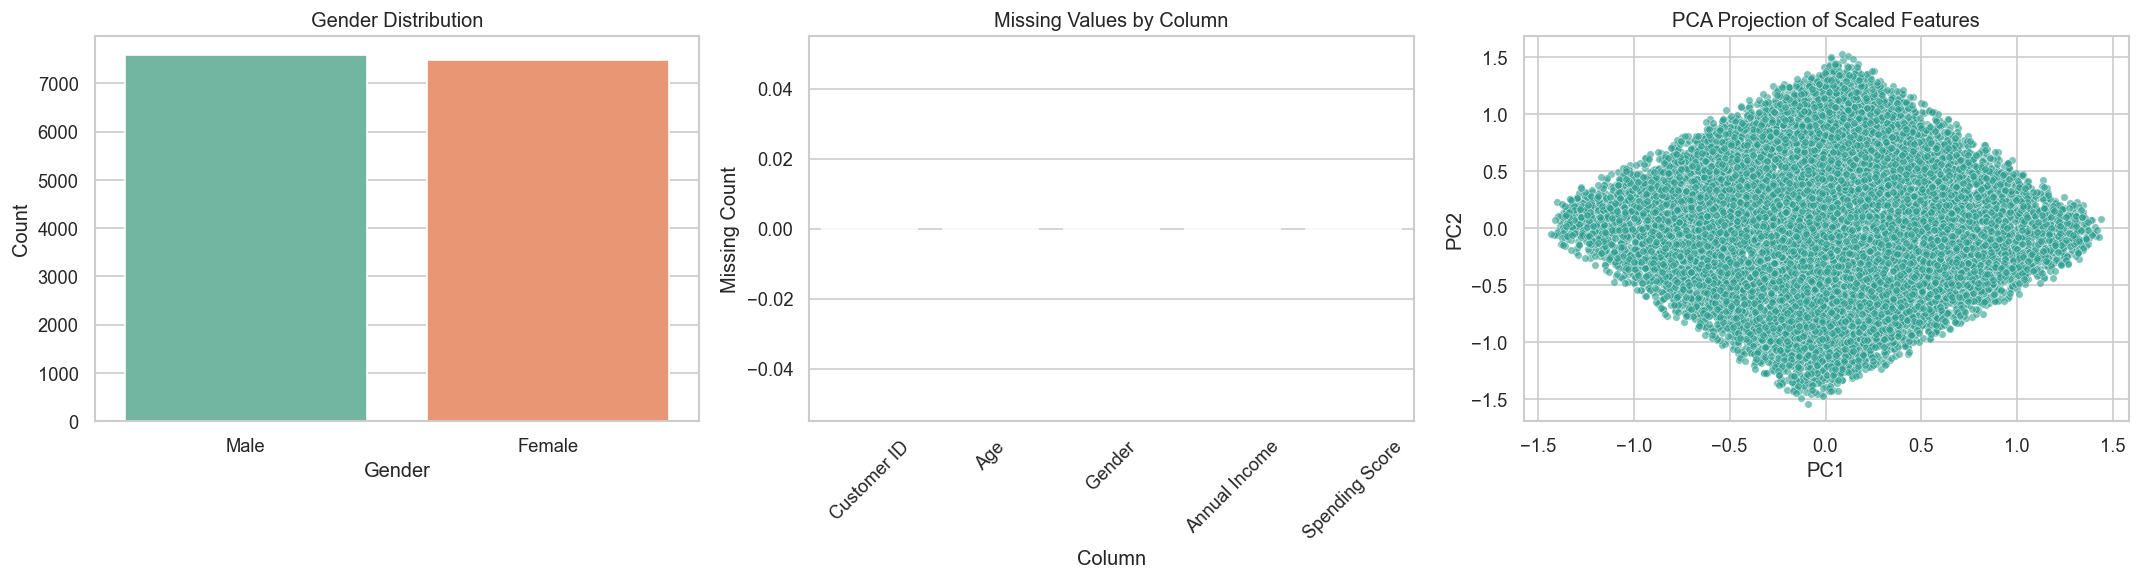

In [10]:
# Preprocessing visuals for the report
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x=gender_df.index, y=gender_df['Count'], ax=axes[0], palette='Set2')
axes[0].set_title('Gender Distribution')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')

sns.barplot(x=missing_df.index, y=missing_df['Missing Count'], ax=axes[1], palette='Blues_r')
axes[1].set_title('Missing Values by Column')
axes[1].set_xlabel('Column')
axes[1].set_ylabel('Missing Count')
axes[1].tick_params(axis='x', rotation=45)

sns.scatterplot(x=X_pca['PC1'], y=X_pca['PC2'], s=20, alpha=0.6, ax=axes[2], color='#2a9d8f')
axes[2].set_title('PCA Projection of Scaled Features')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')

plt.tight_layout()
plt.show()